<a href="https://colab.research.google.com/github/ParbatiDebbarma/Porter-Neural_Networks_Regression/blob/main/Porter_NN_Regression_Business_Case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Porter: Neural Networks Regression**

## **About Porter :**

Porter is India's Largest Marketplace for Intra-City Logistics. Leader in the country's $40 billion intra-city logistics market, Porter strives to improve the lives of 1,50,000+ driver-partners by providing them with consistent earning & independence. Currently, the company has serviced 5+ million customers

Porter works with a wide range of restaurants for delivering their items directly to the people.

## **Problem Statement:**

Porter has a number of delivery partners available for delivering the food, from various restaurants and wants to get an estimated delivery time that it can provide the customers on the basis of what they are ordering, from where and also the delivery partners.

## **Data Dictionary**

Each row in this file corresponds to one unique delivery. Each column corresponds to a feature as explained below.

- **market_id** : integer id for the market where the restaurant lies
- **created_at** : the timestamp at which the order was placed
- **actual_delivery_time** : the timestamp when the order was delivered
- **store_primary_category** : category for the restaurant
- **order_protocol** : integer code value for order protocol(how the order was placed i.e, through porter, call to restaurant, pre booked, third part etc)
- **total_items:**
- **subtotal** : final price of the order
- **num_distinct_items** : the number of distinct items in the order
- **min_item_price** : price of the cheapest item in the order
- **max_item_price** : price of the costliest item in order
- **total_onshift_partners** : number of delivery partners on duty at the time order was placed
- **total_busy_partners** : number of delivery partners attending to other tasks
- **total_outstanding_orders** : total number of orders to be fulfilled at the moment
- **estimated_store_to_consumer_driving_duration** : approximate travel time from restaurant to customer

## **Imports**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

## **Understanding Data Structure**

In [ ]:
df = pd.read_csv('/content/data_2.csv')
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [ ]:
# Data Types and memory
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

**Observations:**
All 14 columns have **no missing values** (175,777 non-null each); only the two timestamp fields are still **object** dtype and should be parsed to `datetime`.


---



In [ ]:
# Statistical summaries
num_summary = df.describe(include=['int', 'float']).T #numerical columns
cat_summary = df.describe(include=['object', 'category']).T #categorical columns

In [ ]:
print("\nNumeric summary (transpose):\n")
display(num_summary)


Numeric summary (transpose):



,count,mean,std,min,25%,50%,75%,max
market_id,175777.0,2.743726,1.330963,1.0,2.0,2.0,4.0,6.0
store_primary_category,175777.0,35.887949,20.728254,0.0,18.0,38.0,55.0,72.0
order_protocol,175777.0,2.911752,1.513128,1.0,1.0,3.0,4.0,7.0
total_items,175777.0,3.204976,2.674055,1.0,2.0,3.0,4.0,411.0
subtotal,175777.0,2697.111147,1828.554893,0.0,1412.0,2224.0,3410.0,26800.0
num_distinct_items,175777.0,2.675060,1.625681,1.0,1.0,2.0,3.0,20.0
min_item_price,175777.0,684.965433,519.882924,-86.0,299.0,595.0,942.0,14700.0
max_item_price,175777.0,1160.158616,560.828571,0.0,799.0,1095.0,1395.0,14700.0
total_onshift_dashers,175777.0,44.918664,34.544724,-4.0,17.0,37.0,66.0,171.0
total_busy_dashers,175777.0,41.861381,32.168505,-5.0,15.0,35.0,63.0,154.0


**Obseravtions:**
* **Extreme skew/outliers:** basket size and spend are heavy-tailed (e.g., `total_items` up to **411**, `subtotal` up to **26,800**), so we’ll need outlier handling and possibly log/winsorization.
* **Data quality flags in ops features:** impossible values appear (`total_busy_dashers` min **-5**, `total_outstanding_orders` min **-6**, drive duration min **0**), so clipping/cleanup is required before modeling.




---



In [ ]:
print("\nCategorical summary (transpose):\n")
display(cat_summary)


Categorical summary (transpose):



,count,unique,top,freq
created_at,175777,162649,2015-02-11 19:50:43,6
actual_delivery_time,175777,160344,2015-02-15 04:18:47,5


**Observations**
* Both `created_at` and `actual_delivery_time` are **high-cardinality timestamp strings** (160k+ unique) with tiny top frequencies, so they should be **parsed to datetime** and **not one-hot encoded**.
* We’ll **derive features from them** (e.g., hour-of-day, day-of-week, weekend/holiday, time since previous order) and use **`actual_delivery_time - created_at`** to build the target duration.


---



In [ ]:
# Shape
print(f'No. of Rows in df : {df.shape[0]}\nNo. of Columns in df : {df.shape[1]}')

No. of Rows in df : 175777
No. of Columns in df : 14


In [ ]:
# Duplicates Check
df.duplicated().sum()

np.int64(0)

**Observations:**
Theer are no duplicates in the Dataframe



---



In [ ]:
# Unique values per column
df.nunique()

,0
market_id,6
created_at,162649
actual_delivery_time,160344
store_primary_category,73
order_protocol,7
total_items,54
subtotal,8182
num_distinct_items,20
min_item_price,2251
max_item_price,2585


**Observations :**
* `created_at`/`actual_delivery_time` are **very high-cardinality**.
* `market_id` (6) and `order_protocol` (7) are **low-cardinality categoricals** → simple encoding works `store_primary_category` (73) is moderate/high.
* Monetary and ops features (`subtotal`, prices, onshift/busy/outstanding, drive duration) are **continuous with wide ranges**.

## **Data preprocessing**

### **Data Type Conversions**

In [ ]:
# Timestamp
df['created_at'] = pd.to_datetime(df['created_at'], errors = 'coerce', utc = False)
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'], errors = 'coerce', utc = False)

In [ ]:
# Integer / Counts
count_cols  = ['total_items', 'num_distinct_items', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders']

for i in count_cols:
    df[i] = pd.to_numeric(df[i], errors = 'coerce')  #coerce bad strings
    if i in ['total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders']:
        df[i] = df[i].round(0)
    df[i] = df[i].astype('Int64')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     175777 non-null  float64       
 1   created_at                                    175777 non-null  datetime64[ns]
 2   actual_delivery_time                          175777 non-null  datetime64[ns]
 3   store_primary_category                        175777 non-null  int64         
 4   order_protocol                                175777 non-null  float64       
 5   total_items                                   175777 non-null  Int64         
 6   subtotal                                      175777 non-null  int64         
 7   num_distinct_items                            175777 non-null  Int64         
 8   min_item_price                                175777 n

**Insights:**
* **Timestamps fixed:** `created_at` and `actual_delivery_time` are now proper `datetime64[ns]`, so we can safely engineer hour/day features and compute the target duration.
* **Categoricals set:** `market_id`, `store_primary_category`, and `order_protocol` are `category`, preventing fake numeric order and reducing memory.
* **Numeric integrity:** All other fields are numeric (`Int64`), with **no loss in non-null counts**.



---



### **Freature Engineering**

**Creating Target column**

In [ ]:
# Computing delivery time (minutes) by subtracting order timestamp from delivery timestamp

df['delivery_duration'] = (
    df['actual_delivery_time']
      .sub(df['created_at'])          # Computing time delta (delivery - order)
      .dt.total_seconds()             # Getting total seconds from timedelta
      .div(60)                        # Converting seconds to minutes
      .astype(float)                  # Casting to float for downstream math
)

# Dropping delivery timestamp to avoid leakage after creating the target
df = df.drop(columns=['actual_delivery_time'])

**Sanity check for the Delhivery time**

In [ ]:
# Calculating basic sanity counts for delivery_duration
nonpos = (df['delivery_duration'] <= 0).sum()   # Counting durations that are non-positive (<= 0 min)
short  = (df['delivery_duration'] < 5).sum()    # Counting durations that are very short (< 5 min)
long   = (df['delivery_duration'] > 180).sum()  # Counting durations that are very long (> 180 min)

# Printing the sanity check results for quick review
print(f"\nNon-positive durations (<=0): {nonpos}")
print(f"Very short (<5 min): {short}")
print(f"Very long (>180 min): {long}")


Non-positive durations (<=0): 0
Very short (<5 min): 0
Very long (>180 min): 0


**Understanding pandas datetime data type and what function it provides by default**

In [ ]:
'''Inspecting common pandas .dt accessors on 'created_at' for quick reference
   (Confirming available fields and printing a small sample to verify values)'''

# Selecting a small sample of timestamps for display
sample_ts = df['created_at'].head(5)

# Building a DataFrame demonstrating commonly used .dt attributes/methods
dt_demo = pd.DataFrame({
    'created_at': sample_ts,    # Showing raw timestamp
    'year':        sample_ts.dt.year,
    'month':       sample_ts.dt.month,
    'day':         sample_ts.dt.day,
    'hour':        sample_ts.dt.hour,
    'minute':      sample_ts.dt.minute,
    'second':      sample_ts.dt.second,
    'dayofweek':   sample_ts.dt.dayofweek,
    'day_name':    sample_ts.dt.day_name(),
    'date':        sample_ts.dt.date,
    'time':        sample_ts.dt.time,
    'quarter':     sample_ts.dt.quarter,
    'days_in_mon': sample_ts.dt.daysinmonth})

# Adding ISO calendar breakdown
iso = sample_ts.dt.isocalendar()  # Getting ISO calendar as a DataFrame
dt_demo['iso_year'] = iso['year']
dt_demo['iso_week'] = iso['week']
dt_demo['iso_day']  = iso['day']

# Printing the demo table for quick verification
print("Datetime .dt demo (first 5 rows):")
print(dt_demo.to_string(index=False))

Datetime .dt demo (first 5 rows):
         created_at  year  month  day  hour  minute  second  dayofweek day_name       date     time  quarter  days_in_mon  iso_year  iso_week  iso_day
2015-02-06 22:24:17  2015      2    6    22      24      17          4   Friday 2015-02-06 22:24:17        1           28      2015         6        5
2015-02-10 21:49:25  2015      2   10    21      49      25          1  Tuesday 2015-02-10 21:49:25        1           28      2015         7        2
2015-02-16 00:11:35  2015      2   16     0      11      35          0   Monday 2015-02-16 00:11:35        1           28      2015         8        1
2015-02-12 03:36:46  2015      2   12     3      36      46          3 Thursday 2015-02-12 03:36:46        1           28      2015         7        4
2015-01-27 02:12:36  2015      1   27     2      12      36          1  Tuesday 2015-01-27 02:12:36        1           31      2015         5        2


* The timestamps are **properly parsed** to `datetime64[ns]`—we can extract components like year/month/day/hour correctly.
* `dayofweek` uses **0=Mon … 6=Sun** (matching the shown day names)
* Calendar logic looks sane: all rows are in **Q1**, February shows **28 days** vs January **31**, confirming `.dt` accessors are working as expected for downstream feature engineering.


---



**Order Time**

In [ ]:
# Extracting time-of-order features from created_at

# Creating hour in 24-hour format (0–23)
df['order_hour'] = df['created_at'].dt.hour.astype('Int64')  # Ensuring integer dtype

# Creating day index as 1–7 where 1=Monday, 7=Sunday
df['order_day'] = (df['created_at'].dt.dayofweek + 1).astype('Int64')  # Mapping pandas 0–6 to 1–7

# Dropping order timestamp after deriving time features and target
df = df.drop(columns=['created_at'])

# Printing a quick preview to verify values
print(df[['order_hour', 'order_day']].head())

   order_hour  order_day
0          22          5
1          21          2
2           0          1
3           3          4
4           2          2


**Converting estimated drive duration from seconds to minutes**

In [ ]:
# Ensuring numeric, dividing by 60, and casting to float for downstream math
df['estimated_store_to_consumer_driving_duration'] = pd.to_numeric(df['estimated_store_to_consumer_driving_duration'], errors='coerce').div(60).astype(float)

In [ ]:
df.sample(10)

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,delivery_duration,order_hour,order_day
52496,4.0,68,3.0,1,1195,1,995,995,80,64,93,7.633333,41.0,1,7
54903,1.0,65,1.0,6,5643,4,299,2099,45,45,53,7.016667,51.0,1,7
92366,4.0,50,3.0,3,2200,3,550,1050,115,70,109,6.400000,40.0,1,6
104856,1.0,13,4.0,2,1618,2,589,1029,9,4,4,5.883333,43.0,0,6
28127,2.0,55,1.0,2,4110,1,2055,2055,69,72,118,6.733333,54.0,2,2
135041,2.0,4,1.0,1,1475,1,1475,1475,48,38,39,10.550000,35.0,21,2
152743,4.0,20,1.0,6,3975,6,200,995,47,36,53,8.666667,50.0,1,5
62701,1.0,10,3.0,3,2965,2,675,795,22,20,19,11.633333,48.0,1,4
49798,2.0,59,5.0,2,2700,1,1300,1300,113,107,201,11.966667,64.0,3,6
21852,5.0,7,5.0,7,3435,6,95,1295,28,14,28,5.033333,43.0,1,6


* **Target ready:** Created `delivery_duration` (minutes) from `actual_delivery_time − created_at`.
* **Time signals:** Extracted `order_hour`, `order_day` (1=Mon…7=Sun), `order_month` (1–12).
* **Drive time usable:** Converted `estimated_store_to_consumer_driving_duration` to **minutes** (kept as a strong predictor of distance/traffic).
* **Types sane:** True categoricals (`market_id`, `store_primary_category`, `order_protocol`) are categorical; remaining fields are numeric for modeling.
* **Dataset trimmed for modeling:** `created_at` removed after deriving features and dropped `actual_delivery_time` to prevent leakage.


### **Handling Negatives**

In [ ]:
# Statistical summaries
num_summary = df.describe(include=['int', 'float']).T #numerical columns
#cat_summary = df.describe(include=['object', 'category']).T #categorical columns

In [ ]:
print("\nNumeric summary (transpose):\n")
display(num_summary)


Numeric summary (transpose):



,count,mean,std,min,25%,50%,75%,max
market_id,175777.0,2.743726,1.330963,1.0,2.0,2.0,4.0,6.0
store_primary_category,175777.0,35.887949,20.728254,0.0,18.0,38.0,55.0,72.0
order_protocol,175777.0,2.911752,1.513128,1.0,1.0,3.0,4.0,7.0
total_items,175777.0,3.204976,2.674055,1.0,2.0,3.0,4.0,411.0
subtotal,175777.0,2697.111147,1828.554893,0.0,1412.0,2224.0,3410.0,26800.0
num_distinct_items,175777.0,2.67506,1.625681,1.0,1.0,2.0,3.0,20.0
min_item_price,175777.0,684.965433,519.882924,-86.0,299.0,595.0,942.0,14700.0
max_item_price,175777.0,1160.158616,560.828571,0.0,799.0,1095.0,1395.0,14700.0
total_onshift_dashers,175777.0,44.918664,34.544724,-4.0,17.0,37.0,66.0,171.0
total_busy_dashers,175777.0,41.861381,32.168505,-5.0,15.0,35.0,63.0,154.0


* Some fields had **physically impossible negatives** (`min_item_price`, on-shift/busy dashers, outstanding orders). We’re **enforcing validity** by flooring them to **0** (e.g., freebies for price, zero counts for ops).
* After flooring, we also **constrain consistency** (e.g., `total_busy_dashers ≤ total_onshift_dashers`) to keep the dataset realistic and prevent the model from learning from corrupted signals.


In [ ]:
# Setting negative values to valid floor values as per business rule

# Making negative min_item_price equal to 0 (treating as freebies)
df['min_item_price'] = df['min_item_price'].astype('float').clip(lower=0).round().astype('Int64')


# Making negative ops counts equal to 0 (dashers/orders cannot be negative)
ops_cols = ['total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders']
for i in ops_cols:
    df[i] = df[i].astype('float').clip(lower=0).round().astype('Int64')

In [ ]:
'''Checked for rows where busy dashers was bigger than dashers on shift (which can’t happen).
For those rows, busy dashers were set equal to on-shift dashers so the numbers make sense.'''

# Ensuring busy dashers do not exceed onshift dashers
over_busy = df['total_busy_dashers'] > df['total_onshift_dashers']
df.loc[over_busy, 'total_busy_dashers'] = df.loc[over_busy, 'total_onshift_dashers'                    ]

In [ ]:
# Printing quick validation counts
print("Negatives after fix:",
      (df[['min_item_price'] + ops_cols] < 0).sum().to_dict())
print("busy>onshift pairs after fix:",
      int((df['total_busy_dashers'] > df['total_onshift_dashers']).sum()))

Negatives after fix: {'min_item_price': 0, 'total_onshift_dashers': 0, 'total_busy_dashers': 0, 'total_outstanding_orders': 0}
busy>onshift pairs after fix: 0


All formerly negative values were floored to 0, and there are **no** remaining inconsistencies—`total_busy_dashers` never exceeds `total_onshift_dashers`.


---



## **Handling Null Values**

In [ ]:
df.isnull().sum().sum()

np.int64(0)

**Observation:**

There are no Null Values in the dataframe

## **Encoding categorical columns**

### **Frequency Encoding**

**Intuition behind choosing Frequency Encoding:**

* **IDs → usable signal:** Your “categoricals” are numeric IDs with no true order. Frequency encoding converts each ID into “how common it is,” which is a meaningful, scale-friendly signal for both NN and RF—without inventing fake ordinality.

* **Compact and fast:** One-hot on `store_primary_category` (73+) would explode columns and slow training/plots. Frequency encoding keeps **one column per feature**, preserving model capacity while avoiding sparsity.

* **Robust to new categories & leakage-safe:** Unseen IDs at inference naturally map to **0** (or tiny ε), so the model degrades gracefully. And unlike target encoding, frequency uses **no target info**, so it’s simple and leakage-free for your upcoming visualizations and models.


In [ ]:
#defining categorical columns
cat_cols = ['market_id', 'store_primary_category', 'order_protocol']

# Creating a working copy as df encoded
df_encoded = df.copy()

# Building frequency maps on current df (using relative frequencies)
# (value_counts(normalize = True) is returning proportions)
freq_maps = {
    col: df[col].value_counts(normalize = True)
    for col in cat_cols
}


# Replacing original ID columns with their relative frequencies
for col in cat_cols:
    df_encoded[col] = (df_encoded[col]
                       .map(freq_maps[col])           # Mapping IDs to their frequency
                       .astype('float32'))           # Keeping memory small and numeric for scaling

In [ ]:
df_encoded.sample(3)

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,delivery_duration,order_hour,order_day
78853,0.262958,0.000290,0.118844,7,2475,4,145,1295,7,7,6,12.150000,48.0,17,6
167968,0.098181,0.000626,0.098113,1,1295,1,1295,1295,10,9,9,10.383333,40.0,19,1
135228,0.119896,0.031688,0.275372,3,1220,3,275,645,0,0,0,11.700000,48.0,4,3


## **Data visualization**

### **Univariate Analysis**

**Orders by Hour (0–24) and Order by day (1-7)**

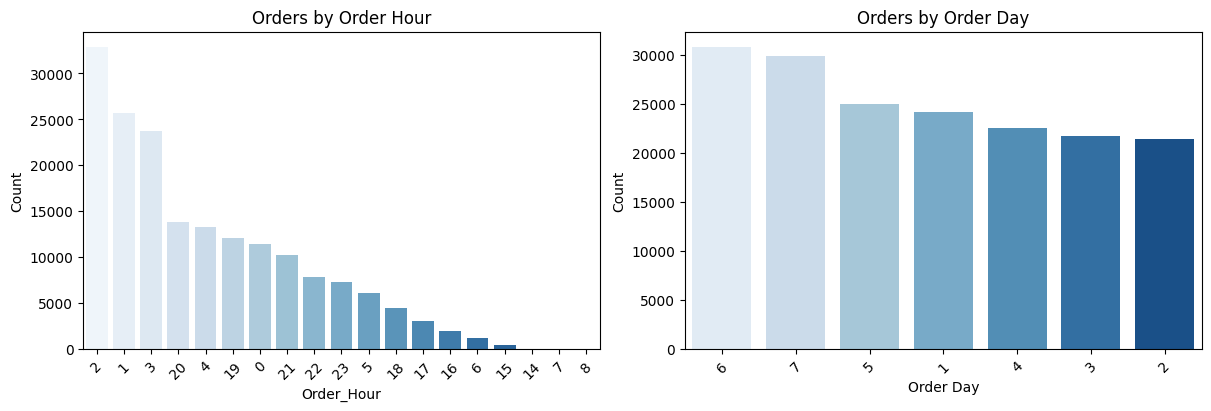

In [ ]:
# creating two side-by-side count plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# LEFT: Orders by hour (sorted by frequency — quickest way to see peak hours)
sns.countplot(x='order_hour', data=df,
              order=df['order_hour'].value_counts().index,
              palette='Blues', ax=ax[0])
ax[0].set(title='Orders by Order Hour', xlabel='Order_Hour', ylabel='Count')
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(False)

# RIGHT: Orders by day (sorted by frequency — shows busiest days first)
sns.countplot(x='order_day', data=df,
              order=df['order_day'].value_counts().index,
              palette='Blues', ax=ax[1])
ax[1].set(title='Orders by Order Day', xlabel='Order Day', ylabel='Count')
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(False)

plt.show()

**Observations :**
- **Sharp hour spikes**: A few hours dominate order volume (steep drop after top hours(mostly mid-night)). This suggests clear rush windows where demand clusters tightly.

- **Day-of-week effect**: Days labeled 6(Saturday) and 7(Sunday) are the busiest, while 3 is the lowest in your plot—indicative of a weekend lift and a mid-week dip (if 0=Mon, then 6–7≈Sat–Sun).

---



**Orders by Market Id and Order Protocol**

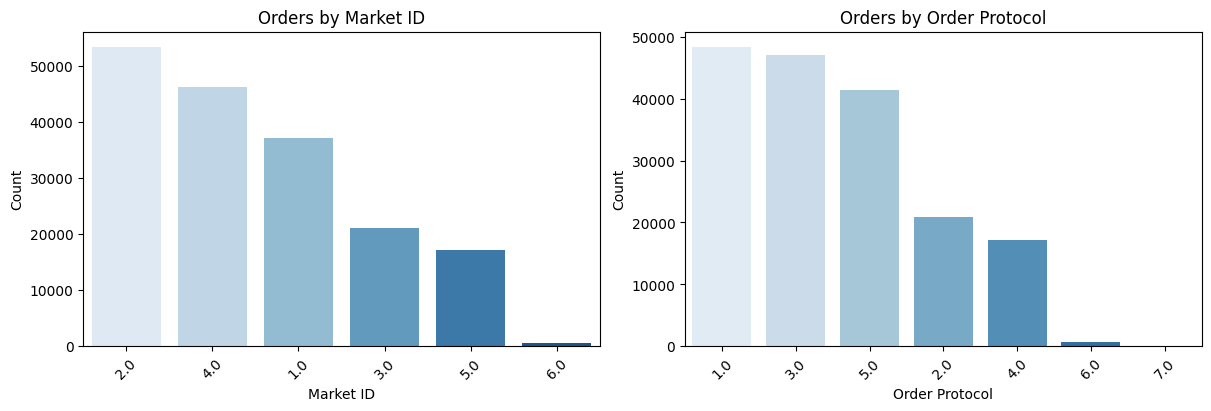

In [ ]:
# creating two side-by-side subplots for quick comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)


# LEFT: Market mix — frequency-sorted to surface dominant markets quickly
sns.countplot(x='market_id', data=df,
              order=df['market_id'].value_counts().index,
              palette='Blues', ax=ax[0])

ax[0].set(title='Orders by Market ID', xlabel='Market ID', ylabel='Count')
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(False)


# RIGHT: Ordering protocol mix — frequency-sorted to show leading protocols first
sns.countplot(x='order_protocol', data=df,
              order=df['order_protocol'].value_counts().index,
              palette='Blues', ax=ax[1])
ax[1].set(title='Orders by Order Protocol', xlabel='Order Protocol', ylabel='Count')
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(False)

plt.show()

**Observations :**

- **Market concentration:** Market IDs 2 and 4 account for the bulk of orders, followed by 1 and 3. 5 is smaller, and 6 is almost negligible → expect class imbalance if you model with market_id as a feature.

- **Operational focus:** Staffing, promotions, and SLAs should be prioritized for markets 2 & 4; market 6 may require a different strategy (growth or de-prioritize).

---



**Top-10 Store Primary Categories**

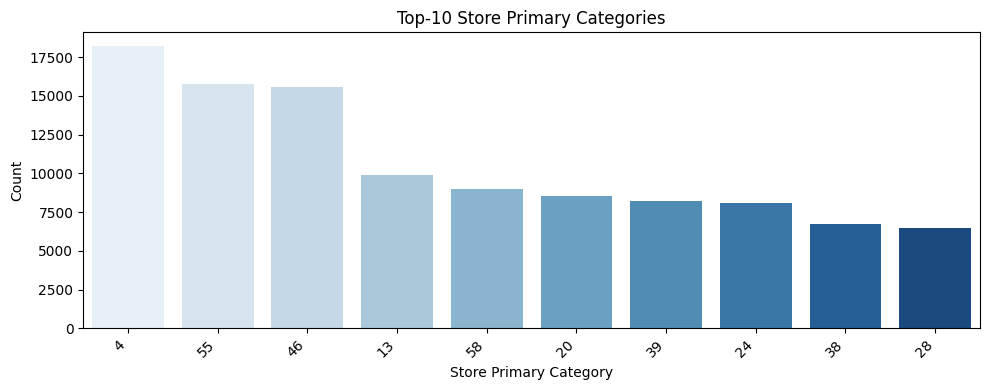

In [ ]:
# selecting the Top-10 categories by frequency
top10 = df['store_primary_category'].value_counts().index[:10]
# subsetting data to only those Top-10 categories for a clean bar chart
sub = df[df['store_primary_category'].isin(top10)]

plt.figure(figsize=(10, 4))

# plotting counts in frequency order so leaders appear first
sns.countplot(x='store_primary_category', data=sub, order=top10, palette='Blues')
plt.title('Top-10 Store Primary Categories')
plt.xlabel('Store Primary Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(False)
plt.show()

**Observations :**
* Category **4** has the most orders; **55** is second.
* Counts decline steadily from first to tenth (long-tail), with **36** the lowest in the Top-10.


---



**Distribution of Subtotal**

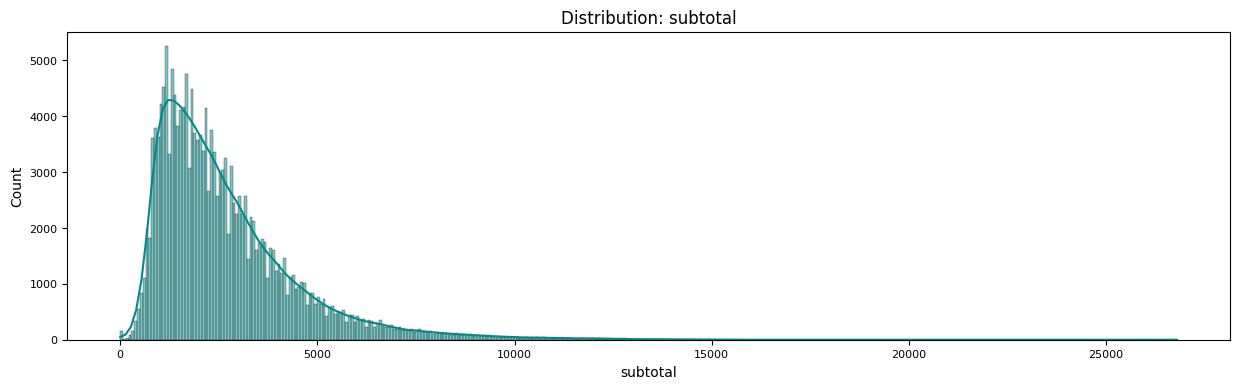

In [ ]:
# plotting subtotal distribution with KDE to see shape and tail
plt.figure(figsize=(15,4))

# histogram of 'subtotal' with density curve
sns.histplot(df["subtotal"], kde=True, color='darkcyan')

# adding titles and axis labels
plt.title("Distribution: subtotal", fontsize=12)
plt.xlabel("subtotal", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.show()

**Observations:**
* The distribution is **right-skewed**: most orders have lower subtotals, with a long tail to high values.
* The peak frequency appears around **1.5k–2.5k** (approx.) and drops steadily after ~3k.
* A few orders have **very high subtotals** (up to ~18k+), far from the main mass.


---



**Distribution of Busy and Onshift Dashers**

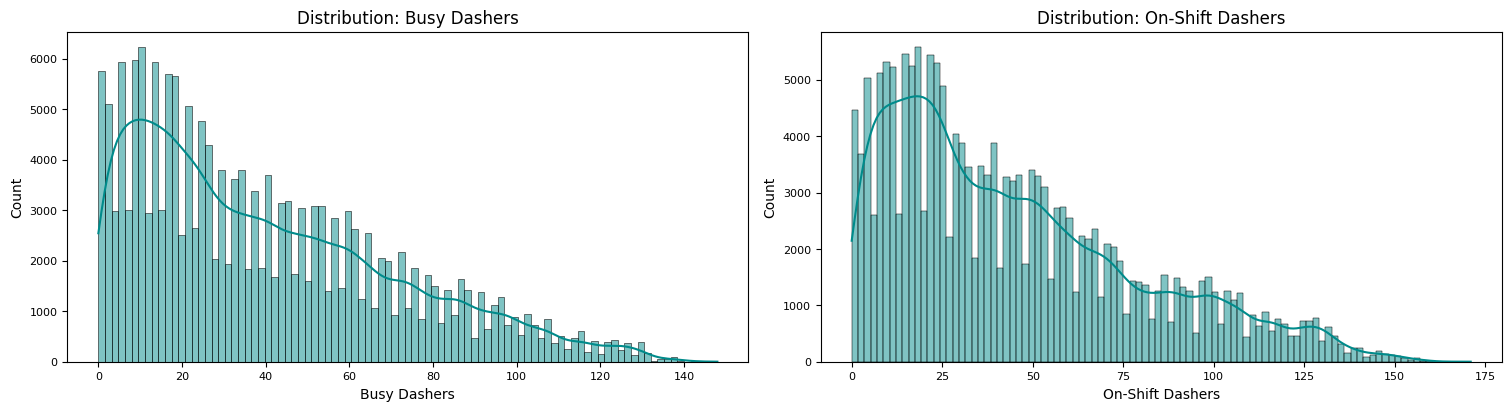

In [ ]:
# creating two side-by-side subplots for quick comparison
fig, ax = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)

# left plot: distribution of busy dashers with KDE overlay
sns.histplot(df["total_busy_dashers"], kde=True, color='darkcyan', ax=ax[0])
ax[0].set_title("Distribution: Busy Dashers", fontsize=12)
ax[0].set_xlabel("Busy Dashers", fontsize=10); ax[0].set_ylabel("Count", fontsize=10)
ax[0].tick_params(axis='both', labelsize=8)

# right plot: distribution of on-shift dashers with KDE overlay
sns.histplot(df["total_onshift_dashers"], kde=True, color='darkcyan', ax=ax[1])
ax[1].set_title("Distribution: On-Shift Dashers", fontsize=12)
ax[1].set_xlabel("On-Shift Dashers", fontsize=10); ax[1].set_ylabel("Count", fontsize=10)
ax[1].tick_params(axis='both', labelsize=8)

# rendering both plots
plt.show()

**Observations :**
* Both distributions are **right-skewed** with long tails to higher counts.
* **Busy dashers** peak in the lower range (around ~10–20) and taper off by ~140+.
* **On-shift dashers** peak slightly higher (around ~20–30) and extend further (up to ~170).
* For most observations, **on-shift counts exceed busy counts**, indicating available capacity during many time points.


---



**Total Outstanding Orders**

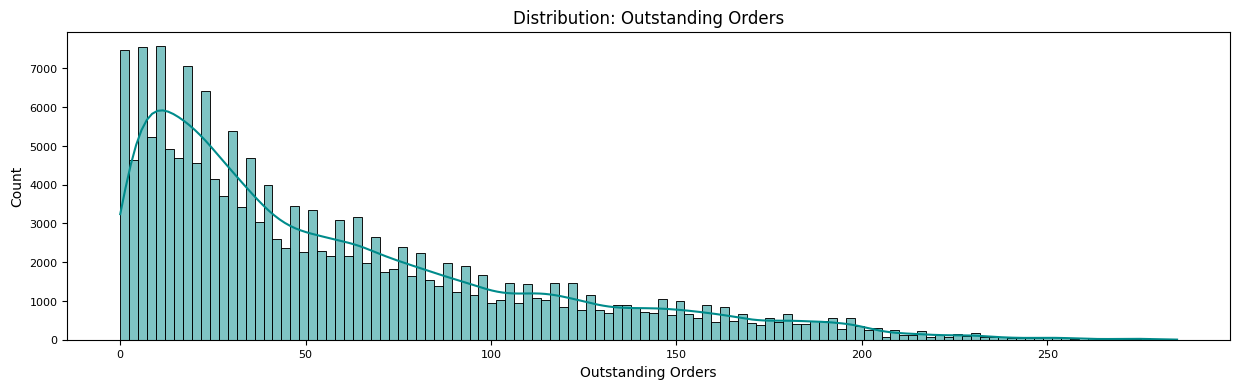

In [ ]:
plt.figure(figsize=(15,4)) # setting the figure size

# plotting outstanding orders' distribution with KDE to see shape and tail
sns.histplot(df["total_outstanding_orders"], kde=True, color= 'darkcyan')


plt.title("Distribution: Outstanding Orders", fontsize=12)
plt.xlabel("Outstanding Orders", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.show()

**Obseravtion :**
* The distribution is **right-skewed**: most time points have **few outstanding orders**.
* There’s a **peak in the low range** (roughly 5–25 orders) and then counts drop steadily.
* A **long tail** extends beyond **200+** outstanding orders (mostly outliers), with a few extreme highs.


---



**Delhivery ETA Vs Actual Duration for Delhivery**

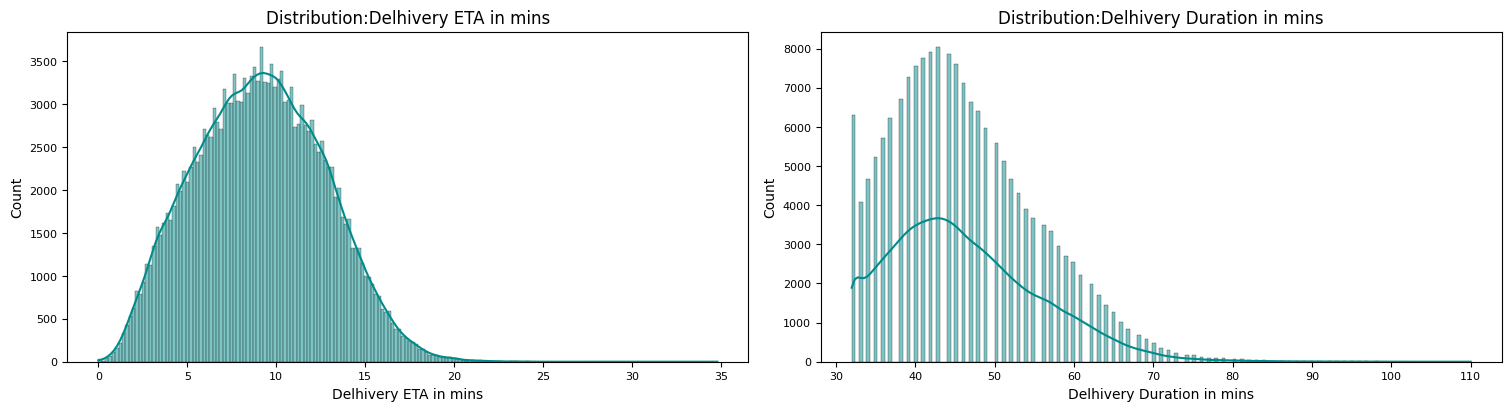

In [ ]:
# creating two side-by-side subplots for ETA vs actual duration
fig, ax = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)

# left: estimated store→consumer driving duration (ETA)
sns.histplot(df["estimated_store_to_consumer_driving_duration"], kde=True, color='darkcyan', ax=ax[0])
ax[0].set_title("Distribution:Delhivery ETA in mins", fontsize=12)      # keep your label text
ax[0].set_xlabel("Delhivery ETA in mins", fontsize=10); ax[0].set_ylabel("Count", fontsize=10)
ax[0].tick_params(axis='both', labelsize=8)

# right: actual delivery duration
sns.histplot(df["delivery_duration"], kde=True, color='darkcyan', ax=ax[1])
ax[1].set_title("Distribution:Delhivery Duration in mins", fontsize=12) # keep your label text
ax[1].set_xlabel("Delhivery Duration in mins", fontsize=10); ax[1].set_ylabel("Count", fontsize=10)
ax[1].tick_params(axis='both', labelsize=8)

# tip: consider standardizing the wording to "Delivery" across plots for consistency
plt.show()

**Observations :**
* **ETA** is unimodal with a peak around **9–11 min** and a **short right tail**; most values sit between **5–15 min**.
* **Delivery duration** centers around **40–50 min** and is **right-skewed** with a **long tail** extending beyond **80–100 min**.
* The spread of delivery duration is **much wider** than ETA.
* Minimum ETA values are near **0–2 min**, while maximums go past **30 min**; delivery duration ranges roughly **30–100+ min**.


**Max Item Price And Min Item Price**

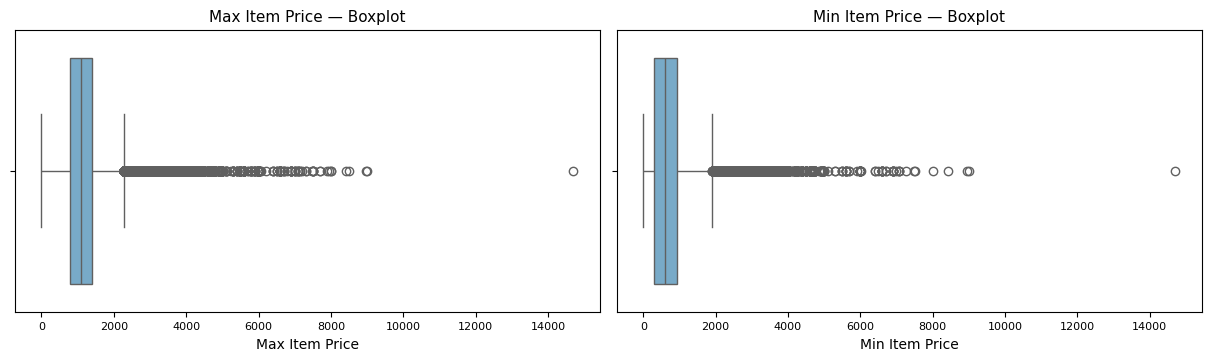

In [ ]:
# creating two side-by-side boxplots for quick comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5), constrained_layout=True)

# left: max item price
sns.boxplot(x=df['max_item_price'].dropna(), palette='Blues', ax=ax[0])
ax[0].set_title('Max Item Price — Boxplot', fontsize=11)
ax[0].set_xlabel('Max Item Price', fontsize=10)
ax[0].tick_params(axis='both', labelsize=8)

# right: min item price
sns.boxplot(x=df['min_item_price'].dropna(), palette='Blues', ax=ax[1])
ax[1].set_title('Min Item Price — Boxplot', fontsize=11)
ax[1].set_xlabel('Min Item Price', fontsize=10)
ax[1].tick_params(axis='both', labelsize=8)

# rendering both plots together
plt.show()

**Observations (Boxplots)**

* Both **max** and **min** item prices are **right-skewed** with **many high outliers**.
* The **central boxes are narrow** compared to the spread of outliers, showing most items sit in a relatively tight price band while a few are very expensive.
* **Min item price** has many values near the low end (close to zero), while occasional **very high “min” prices** appear as outliers.


### **Bivariate Analysis**

**ETA vs Delhivery Duration**

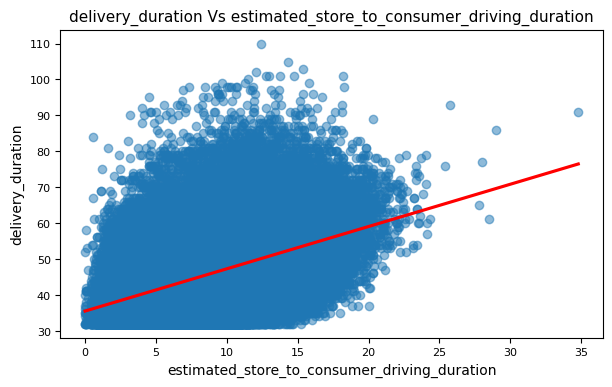

In [ ]:
data  = df[["estimated_store_to_consumer_driving_duration", "delivery_duration"]]

plt.figure(figsize=(7,4))
sns.regplot(x="estimated_store_to_consumer_driving_duration", y="delivery_duration", data=data,
            ci=95,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})
plt.title(f"{"delivery_duration"} Vs {"estimated_store_to_consumer_driving_duration"}", fontsize=11)
plt.xlabel("estimated_store_to_consumer_driving_duration", fontsize=10)
plt.ylabel("delivery_duration", fontsize=10)
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.show()


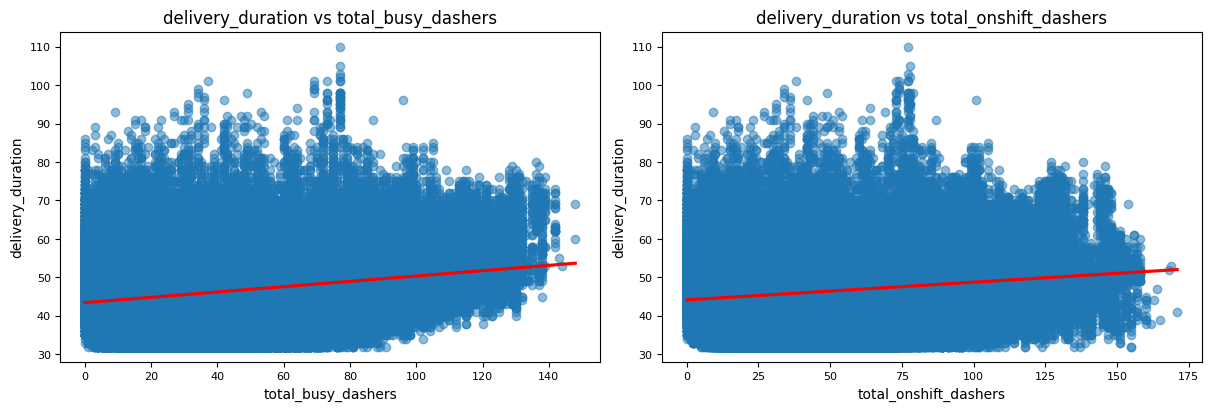

In [ ]:
data = df[["total_busy_dashers", "total_onshift_dashers", "delivery_duration"]]

# subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# LEFT: delivery_duration vs total_busy_dashers
sns.regplot(x="total_busy_dashers", y="delivery_duration", data=data,
            ci=95, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax[0])
ax[0].set(title='delivery_duration vs total_busy_dashers',
          xlabel='total_busy_dashers', ylabel='delivery_duration')
ax[0].tick_params(axis='both', labelsize=8)

# RIGHT: delivery_duration vs total_onshift_dashers
sns.regplot(x="total_onshift_dashers", y="delivery_duration", data=data,
            ci=95, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax[1])
ax[1].set(title='delivery_duration vs total_onshift_dashers',
          xlabel='total_onshift_dashers', ylabel='delivery_duration')
ax[1].tick_params(axis='both', labelsize=8)

plt.show()

**Obseravtions :**
- Both plots show a very weak positive trend (slight upward red line).



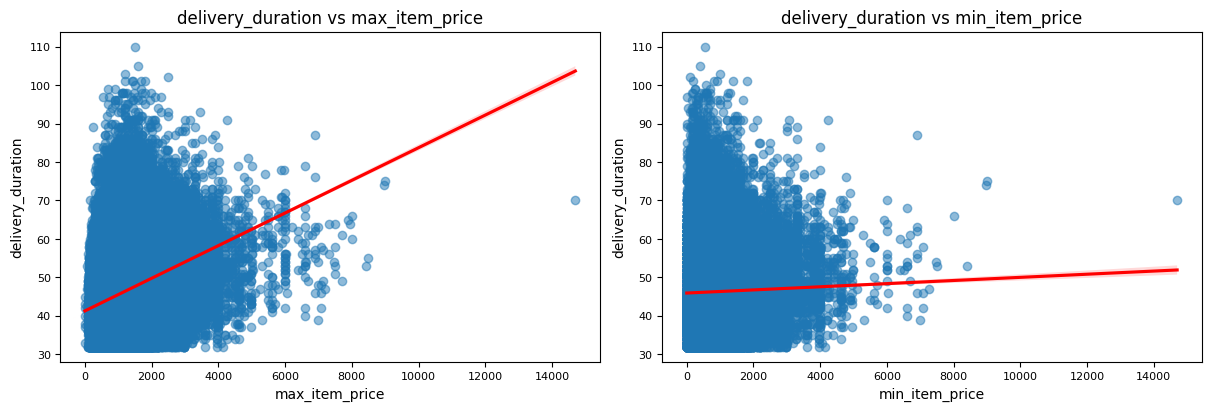

In [ ]:
data = df[["max_item_price", "min_item_price", "delivery_duration"]]

# subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# LEFT: delivery_duration vs max_item_price
sns.regplot(x="max_item_price", y="delivery_duration", data=data,
            ci=95, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax[0])
ax[0].set(title='delivery_duration vs max_item_price',
          xlabel='max_item_price', ylabel='delivery_duration')
ax[0].tick_params(axis='both', labelsize=8)


# RIGHT: delivery_duration vs min_item_price
sns.regplot(x="min_item_price", y="delivery_duration", data=data,
            ci=95, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax[1])
ax[1].set(title='delivery_duration vs min_item_price',
          xlabel='min_item_price', ylabel='delivery_duration')
ax[1].tick_params(axis='both', labelsize=8)

plt.show()


**Obseravtion :**
- **max_item_price** shows a clearer positive slope → higher-priced orders tend to take longer (prep/complexity effect).

- **min_item_price** slope is near flat → the cheapest item in an order doesn’t explain duration much.

---



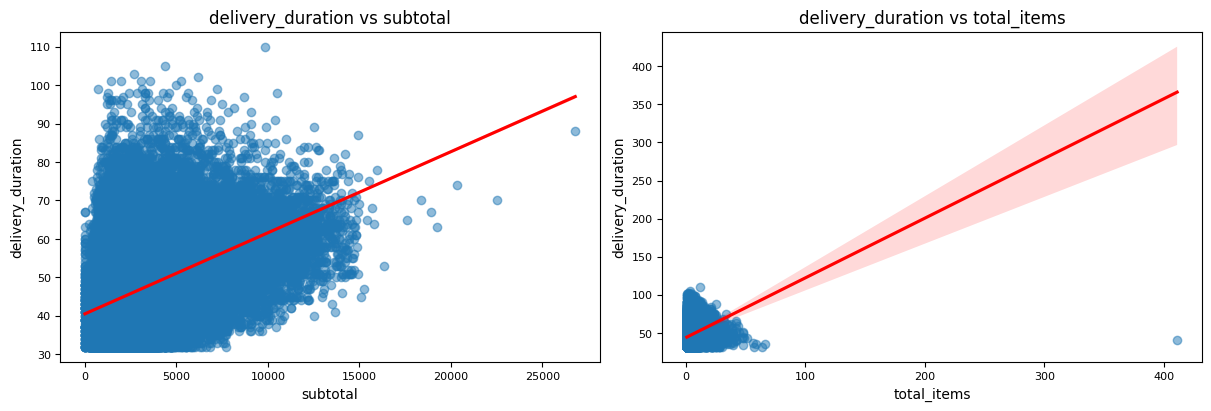

In [ ]:
data = df[["subtotal", "total_items", "delivery_duration"]]

# subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# LEFT: delivery_duration vs subtotal
sns.regplot(x="subtotal", y="delivery_duration", data=data,
            ci=95, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax[0])
ax[0].set(title="delivery_duration vs subtotal",
          xlabel="subtotal", ylabel="delivery_duration")
ax[0].tick_params(axis='both', labelsize=8)

# RIGHT: delivery_duration vs total_items
sns.regplot(x="total_items", y="delivery_duration", data=data,
            ci=95, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax[1])
ax[1].set(title="delivery_duration vs total_items",
          xlabel="total_items", ylabel="delivery_duration")
ax[1].tick_params(axis='both', labelsize=8)

plt.show()


**Observations :**
* **subtotal** vs **delivery_duration**: Clear positive relationship—higher subtotals associate with longer delivery durations, with a dense cluster at low subtotals and increasing spread as subtotal grows.
* **total_items** vs **delivery_duration**: Strong positive trend—more items correlate with longer delivery durations, with noticeable heteroscedasticity (variation increases at higher item counts).


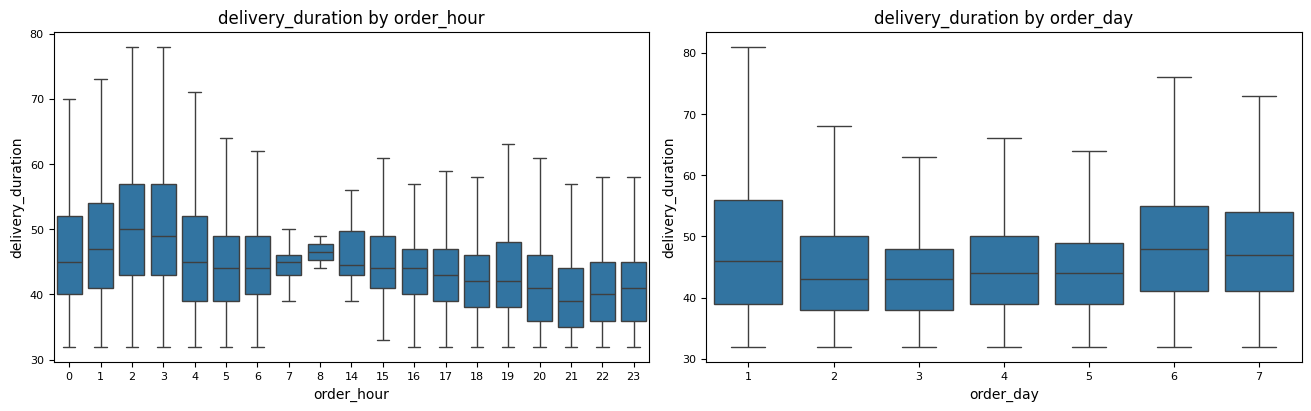

In [ ]:
data = df[["order_hour", "order_day", "delivery_duration"]]

# subplots
fig, ax = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
sns.set_theme(style="whitegrid")

# LEFT: delivery_duration by order_hour (1–24)
sns.boxplot(x="order_hour", y="delivery_duration", data=data,
            showfliers=False, ax=ax[0])
ax[0].set(title="delivery_duration by order_hour",
          xlabel="order_hour", ylabel="delivery_duration")
ax[0].tick_params(axis='both', labelsize=8)

# RIGHT: delivery_duration by order_day (1–7)
sns.boxplot(x="order_day", y="delivery_duration", data=data,
            showfliers=False, ax=ax[1])
ax[1].set(title="delivery_duration by order_day",
          xlabel="order_day", ylabel="delivery_duration")
ax[1].tick_params(axis='both', labelsize=8)

plt.show()

**Observations :**

* **By hour:** Midnight hours (≈1–4) show **higher medians and wider spreads** in `delivery_duration`. Mid-morning to early afternoon (≈9–13) has **lower medians** and **tighter IQRs**. Late afternoon/early evening (≈14–18) shows a **slight uptick in spread** with medians around the low-to-mid 40s.

* **By day:** **Day 1(Monday)** has the **highest median** and **largest variability**. **Days 2–5** have **lower medians** with comparatively **narrower spreads**. **Day 6(Saturday)** again shows a **higher median** and **wide spread**, while **Day 7** sits **between** Day 6 and Days 2–5 in both median and dispersion.


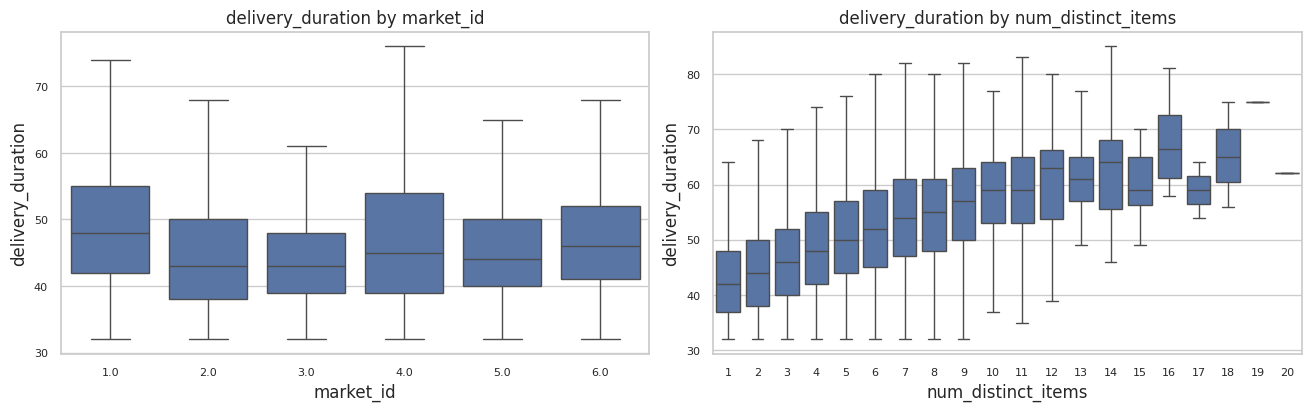

In [ ]:
data = df[["market_id", "num_distinct_items", "delivery_duration"]].dropna()

# subplots
fig, ax = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

# LEFT: delivery_duration by market_id
sns.boxplot(x="market_id", y="delivery_duration", data=data, showfliers=False, ax=ax[0])
ax[0].set(title="delivery_duration by market_id",
          xlabel="market_id", ylabel="delivery_duration")
ax[0].tick_params(axis='both', labelsize=8)

# RIGHT: delivery_duration by num_distinct_items
sns.boxplot(x="num_distinct_items", y="delivery_duration", data=data, showfliers=False, ax=ax[1])
ax[1].set(title="delivery_duration by num_distinct_items",
          xlabel="num_distinct_items", ylabel="delivery_duration")
ax[1].tick_params(axis='x', labelsize=8, rotation=0)
ax[1].tick_params(axis='y', labelsize=8)

plt.show()


**Observations :**

* **delivery_duration by market_id:** Medians differ across markets; markets **1** and **4** show **higher medians** and **wider spreads**, while markets **2, 3, 5, 6** have **lower medians** with comparatively **tighter IQRs**.

* **delivery_duration by num_distinct_items:** Median `delivery_duration` **increases steadily** as `num_distinct_items` rises; dispersion generally **widens** with higher item counts, with several higher-count bins showing **elevated medians** around the 60–70 minute range.


### **Corerlation Heatmap**

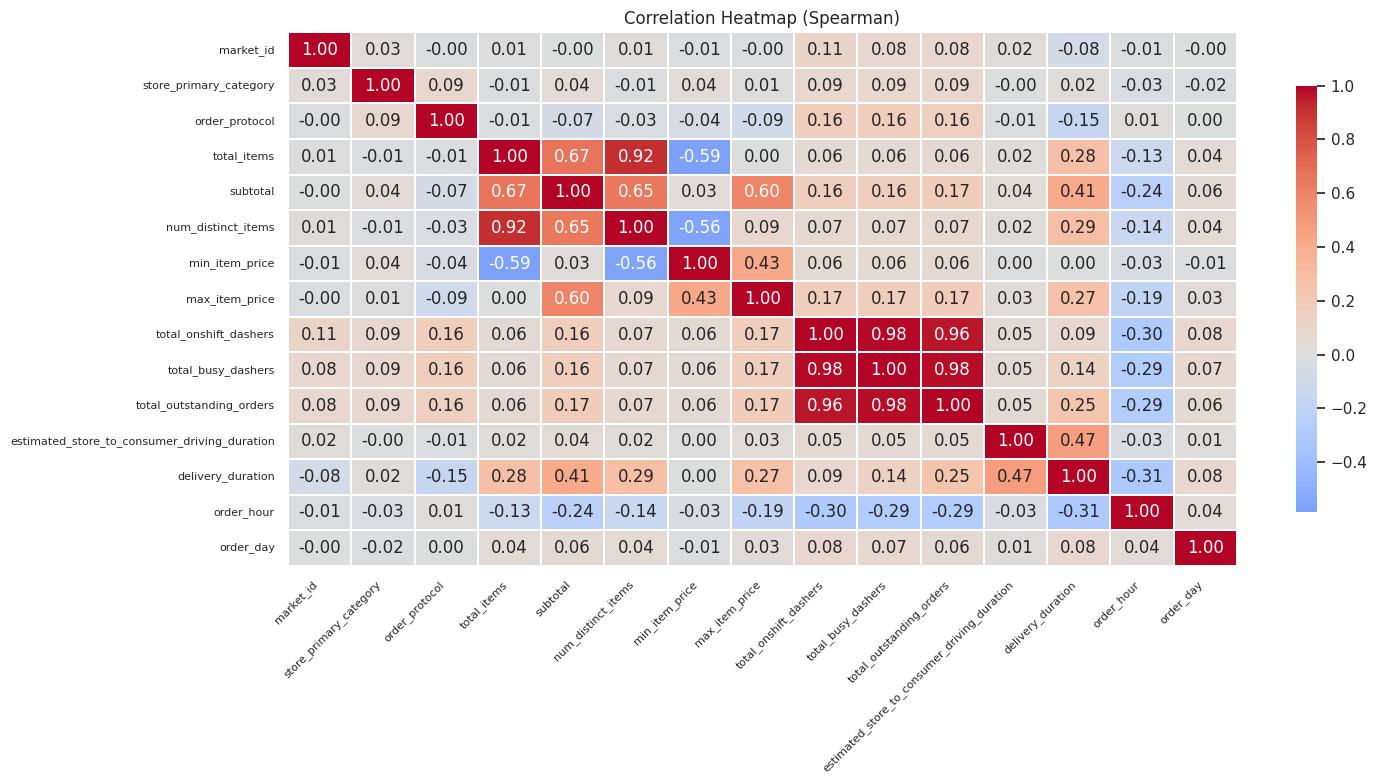

In [ ]:
# 1) keeping only numeric columns
num_df = df.select_dtypes(include="number").dropna()


corr_s = num_df.corr(method="spearman")
plt.figure(figsize=(15,8))
sns.heatmap(corr_s, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", linewidths=0.3, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap (Spearman)", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


**Observations:**

* Order composition moves together: **total_items ↔ num_distinct_items (≈0.92)** and **subtotal ↔ total_items (≈0.67)** / **subtotal ↔ num_distinct_items (≈0.65)**. **min_item_price** is **negatively** related to **total_items (≈−0.59)** and **subtotal (≈−0.56)**.
* Capacity/load metrics are highly collinear: **onshift ↔ busy (≈0.98)**, **busy ↔ outstanding_orders (≈0.98)**, **onshift ↔ outstanding_orders (≈0.96)**.
* `delivery_duration` shows **moderate** correlation with **ETA (≈0.47)** and **subtotal (≈0.41)**, and **weak–moderate** with **total_items / num_distinct_items / max_item_price (≈0.27–0.29)**; it’s **near zero** with **min_item_price** and **order_day**, and **slightly negative** with **order_hour**.

---




## **Outlier Detection**

In [ ]:
def plot_boxplots(df, columns, title):
    """
    Plot boxplots for specified columns.
    Parameters:
    df (pd.DataFrame): Input DataFrame.
    columns (list): Columns to plot.
    title (str): Plot title.
    """
    plt.figure(figsize=(15, 4))
    df[columns].boxplot()
    plt.title(title)
    plt.xticks(rotation=80)
    plt.show()

In [ ]:
num_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

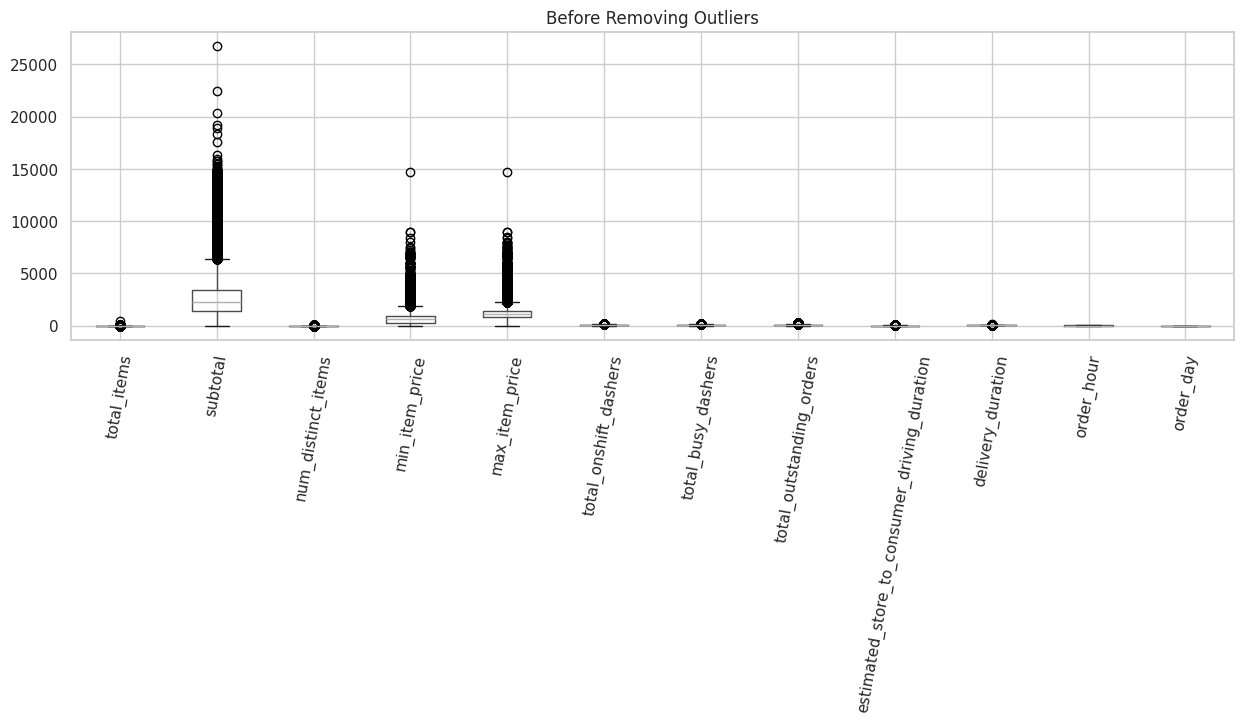

In [ ]:
plot_boxplots(df_encoded, num_cols, "Before Removing Outliers")

**Insights :**

- Several numerical features show heavy presence of outliers, especially:
  - subtotal (very high order values reaching beyond 25,000).
  - min_item_price and max_item_price (spikes into the thousands, far beyond typical ranges).
  - total_items also shows some extreme values (hundreds of items in a single order).
- Features like num_distinct_items , total_onshift_dashers , total_busy_dashers , and total_outstanding_orders also contain outliers but on a smaller scale compared to monetary features.
- The majority of data for most columns is tightly packed at the lower ranges, but the presence of extreme values creates long
whiskers and many outlier points.
- This indicates that a few very large/atypical orders or extreme operational conditions are driving much of the skewness seen in
earlier distributions.
- Operational takeaway: Outlier handling is crucial here — removing or capping these extreme points will help stabilize models and
prevent them from being biased toward rare, unrealistic scenarios.

### **Handling Outliers**

In [ ]:
def remove_outliers_iqr(df, columns, q1=0.01, q3=0.99):
    """
    Remove outliers from specified columns using IQR method.
    Parameters:
    df (pd.DataFrame): Input DataFrame.
    columns (list): List of numerical columns to process.
    q1 (float): Lower quantile
    q3 (float): Upper quantile
    Returns:
    pd.DataFrame: DataFrame with outliers removed.
    """
    cleaned_df = df.copy()
    quantiles = cleaned_df[columns].quantile([q1, q3])
    IQR = quantiles.loc[q3] - quantiles.loc[q1]
    lower = quantiles.loc[q1] - 1.5 * IQR
    upper = quantiles.loc[q3] + 1.5 * IQR
    mask = ((cleaned_df[columns] >= lower) & (cleaned_df[columns] <= upper)).all(axis=1)
    return cleaned_df[mask]


df_no_outliers = remove_outliers_iqr(df_encoded, num_cols)

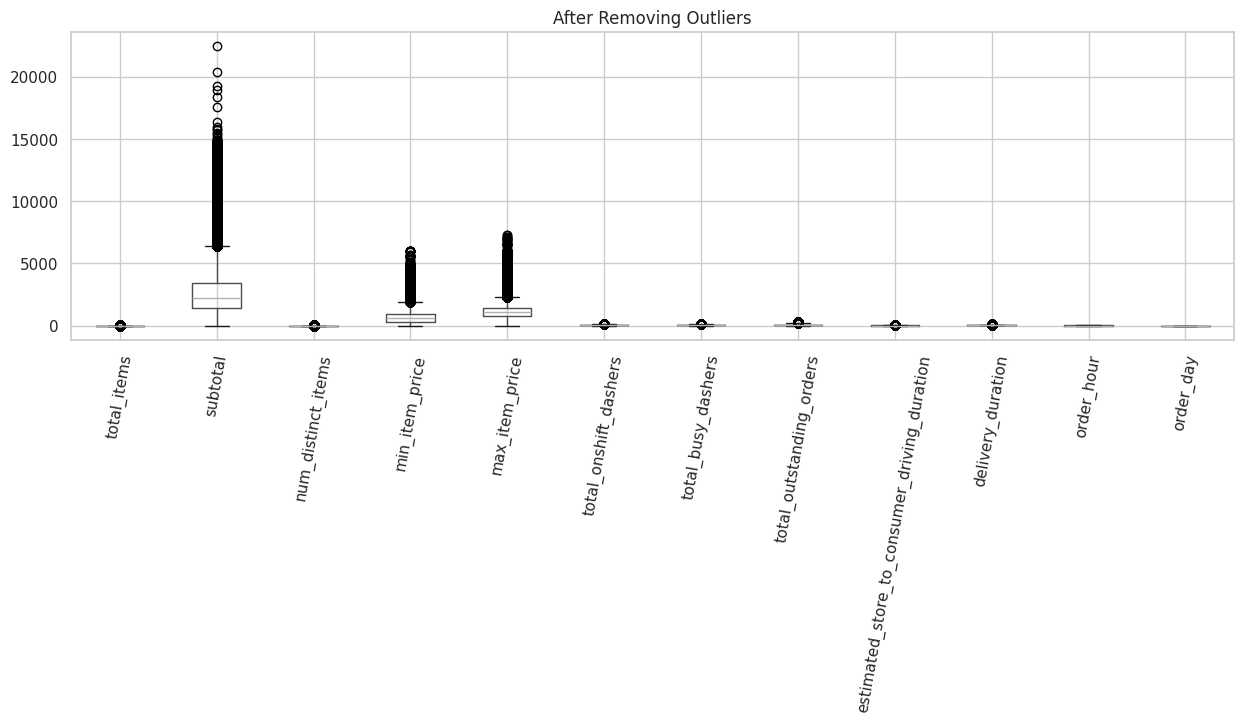

In [ ]:
plot_boxplots(df_no_outliers, num_cols, "After Removing Outliers")

Here’s what changed after the outlier treatment:

* **Upper tails shrank noticeably** for money features—**subtotal**, **min_item_price**, **max_item_price**—with many extreme dots disappearing and much shorter upper whiskers.
* **Medians barely moved**, indicating only extremes were trimmed without shifting the central tendency.
* **Dispersion tightened**: IQRs and overall spread reduced for **subtotal** and for operational loads (**total_onshift_dashers**, **total_busy_dashers**, **total_outstanding_orders**), meaning fewer surge-like spikes remain.
* **Discrete basket-size features** (e.g., **num_distinct_items**, **total_items**) kept their low-count concentration; only a handful of very large baskets were removed—shape is otherwise unchanged.
* **Scale comparability improved** across variables: the y-axis is no longer dominated by a few huge values, making relationships easier to model and visualize.
* **Modeling impact**: with fewer leverage points, gradient/NN/linear models should train more stably (less heteroscedastic noise), while metrics will be less driven by rare, atypical orders.


## **Train Test Split**

In [ ]:
target_col = "delivery_duration"
cat_cols = ['market_id', 'store_primary_category', 'order_protocol']

# 1) Split
X = df.drop(columns=[target_col])
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 2) Align indexes (prevents shape/index mismatches)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# 3) Frequency maps on TRAIN only
freq_maps = {c: X_train[c].value_counts(normalize=True) for c in cat_cols}

# 4) Encode TRAIN -> X_train_enc
X_train_enc = X_train.copy()
for i in cat_cols:
    X_train_enc[i] = X_train[i].map(freq_maps[i])

# 5) Encode TEST -> X_test_enc (same maps)
X_test_enc = X_test.copy()
for i in cat_cols:
    X_test_enc[i] = X_test[i].map(freq_maps[i])

# 6) Sanity check
print(len(X_train_enc), len(y_train))          # should match
print(len(X_test_enc), len(y_test))      # should match

140621 140621
35156 35156


## **Random Forest Model**

In [ ]:
# building the model
rf = RandomForestRegressor(
    n_estimators=100,     # setting number of trees
    random_state=42,      # keeping results reproducible
    n_jobs=-1,             # using all cores to speed up
    verbose=1
)

# training the model on TRAIN
rf.fit(X_train_enc, y_train)

# making predictions on TEST
y_pred = rf.predict(X_test_enc)

# calculating evaluation metrics
r2   = r2_score(y_test, y_pred)                       # computing R^2
mae  = mean_absolute_error(y_test, y_pred)            # computing MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))    # computing RMSE

# printing metrics in a clean format
print("Random Forest Performance on Test Set")
print("-------------------------------------")
print(f"R^2   : {r2:.4f}")
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.1min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s


Random Forest Performance on Test Set
-------------------------------------
R^2   : 0.9569
MAE   : 1.4014
RMSE  : 1.9420


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.1s finished


* **The model explains ~95.7% of the variance in delivery time (high R²).**
* Average absolute error is ~1.4, so predictions are close to actuals on most orders.
* RMSE ~1.94 (higher than MAE) suggests a few larger errors exist but are limited.
* Overall error range is low, indicating strong predictive performance on the test set.


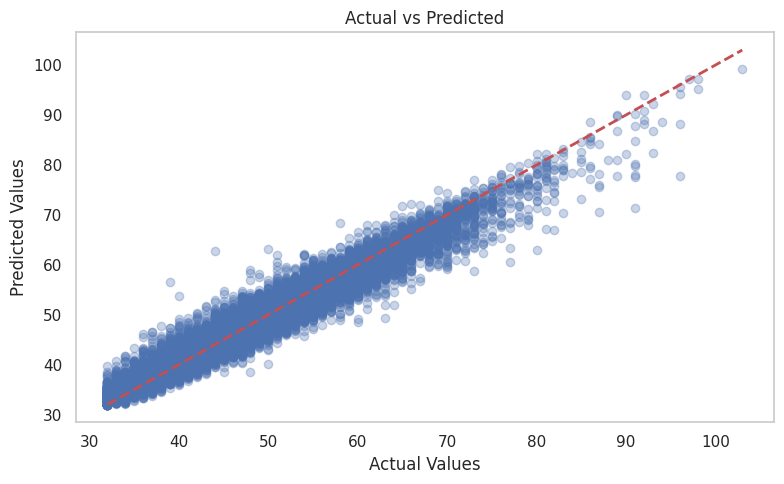

In [ ]:
# setting simple labels/titles (edit if you like)
xlabel = "Actual Values"
ylabel = "Predicted Values"
title  = "Actual vs Predicted"

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
[y_test.min(), y_test.max()],
[y_test.min(), y_test.max()],
'r--',
lw=2,
)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(title)
plt.tight_layout()
plt.grid(False)
plt.show()

## **Neural Network**

**Making Sure there is no NaN in the input data**

In [ ]:
# Ensuring target has no NaN and stays aligned
mask_tr = y_train.notna()
X_train_enc = X_train_enc.loc[mask_tr].copy()
y_train     = y_train.loc[mask_tr].copy()

mask_te = y_test.notna()
X_test_enc  = X_test_enc.loc[mask_te].copy()
y_test      = y_test.loc[mask_te].copy()

# Replacing infs -> NaN, then fill numeric NaNs with TRAIN medians
X_train_enc = X_train_enc.replace([np.inf, -np.inf], np.nan)
X_test_enc  = X_test_enc.replace([np.inf, -np.inf], np.nan)

meds = X_train_enc.median(numeric_only=True)  # compute medians on train
X_train_enc = X_train_enc.fillna(meds)        # fill train NaNs
X_test_enc  = X_test_enc.fillna(meds)         # fill test NaNs with train medians

print("Any NaN in X_train_enc?", X_train_enc.isna().any().any())
print("Any NaN in X_test_enc? ", X_test_enc.isna().any().any())
print("Any NaN in y_train?     ", pd.isna(y_train).any())
print("Any NaN in y_test?      ", pd.isna(y_test).any())


Any NaN in X_train_enc? False
Any NaN in X_test_enc?  False
Any NaN in y_train?      False
Any NaN in y_test?       False


### **Scaling**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)   # fitting on train
X_test_scaled  = scaler.transform(X_test_enc)        # applying same scaler to test

### **Trying different configurations**

**Activation : ReLu; Optimizer: Adam**

Training model: ReLU_Adam_Small
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 4s 972us/step
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1s 997us/step


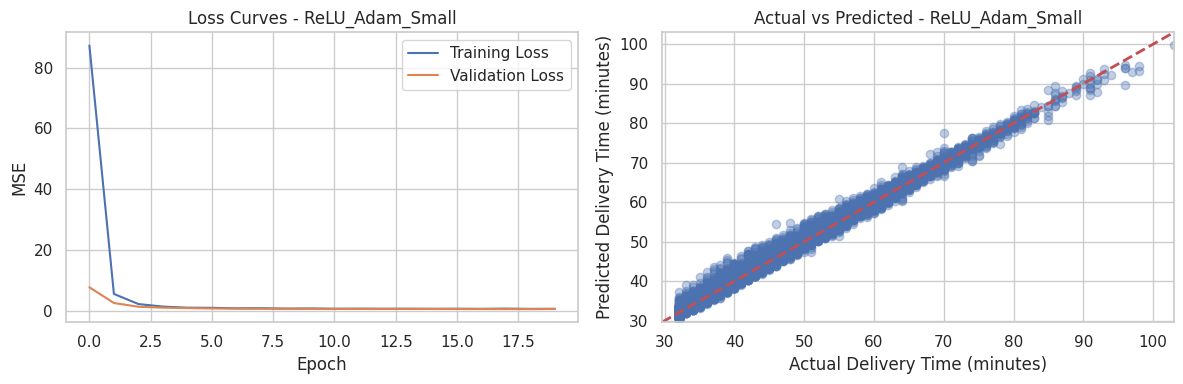

In [ ]:
EPOCHS = 20 #setting the no. of ephocs
BATCH  = 32 #setting the batch-size
tf.random.set_seed(42); np.random.seed(42)

model_A = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])
model_A.compile(optimizer="adam", loss="mse", metrics=["mae"])

print("Training model: ReLU_Adam_Small")
hist_A = model_A.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=0
)

y_trn_A = model_A.predict(X_train_scaled).ravel()
y_tst_A = model_A.predict(X_test_scaled).ravel()



# Plots (two side-by-side)
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(hist_A.history["loss"], label="Training Loss")
ax[0].plot(hist_A.history["val_loss"], label="Validation Loss")
ax[0].set_title("Loss Curves - ReLU_Adam_Small")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("MSE"); ax[0].legend()

lo = float(min(y_test.min(), y_tst_A.min())); hi = float(max(y_test.max(), y_tst_A.max()))
ax[1].scatter(y_test, y_tst_A, alpha=0.35)
ax[1].plot([lo,hi],[lo,hi],'r--',lw=2)
ax[1].set_xlim(lo,hi); ax[1].set_ylim(lo,hi)
ax[1].set_title("Actual vs Predicted - ReLU_Adam_Small")
ax[1].set_xlabel("Actual Delivery Time (minutes)")
ax[1].set_ylabel("Predicted Delivery Time (minutes)")
plt.tight_layout()
plt.show()


**Evaluation Metrics**

In [ ]:
def print_block(title, yt, yp):
    mse = mean_squared_error(yt, yp); rmse = np.sqrt(mse)
    mae = mean_absolute_error(yt, yp); r2 = r2_score(yt, yp)
    print(f"\n{title} metrics for ReLU_Adam_Small:")
    print(f"  MSE : {mse:.4f}\n  RMSE: {rmse:.4f}\n  MAE : {mae:.4f}\n  R2  : {r2:.4f}")

print_block("Train", y_train, y_trn_A)
print_block("Test",  y_test,  y_tst_A)


Train metrics for ReLU_Adam_Small:
  MSE : 0.6873
  RMSE: 0.8290
  MAE : 0.5632
  R2  : 0.9921

Test metrics for ReLU_Adam_Small:
  MSE : 0.6265
  RMSE: 0.7915
  MAE : 0.5648
  R2  : 0.9928


**Inferences:**

- Training and validation loss drop sharply in the first 1–2 epochs and then flatten near zero—learning is fast and stable.
- The two curves stay very close, showing minimal overfitting.
- Actual vs Predicted points hug the 45° line across the full range → strong fit overall.
- Slight spread widens at higher delivery times, hinting at a bit more error in the upper tail.
- No obvious systematic bias at the low–mid range; predictions track actuals closely there.

----

**Activation : Tanh; Optimizer: SGD**

Training model: Tanh_SGD_Large
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


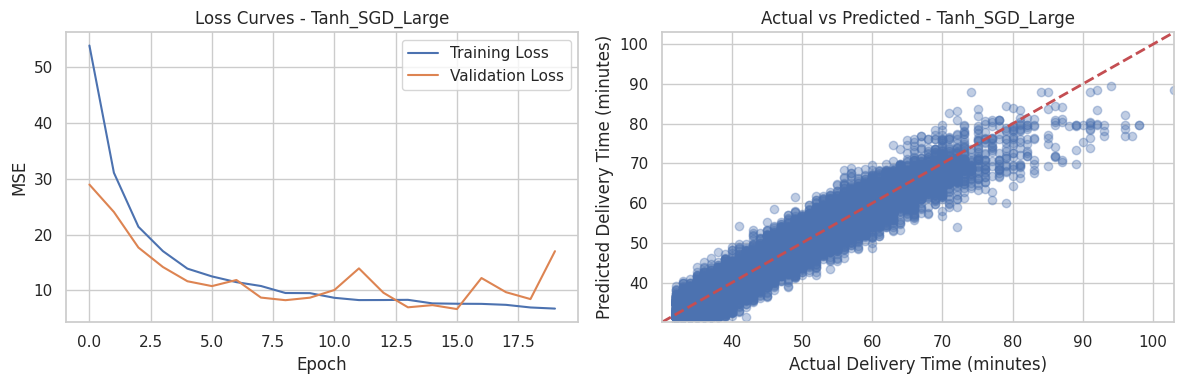

In [ ]:
tf.random.set_seed(42); np.random.seed(42)

model_B = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(256, activation="tanh"),
    Dense(128, activation="tanh"),
    Dense(64,  activation="tanh"),
    Dense(1)
])
model_B.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9),
                loss="mse", metrics=["mae"])

print("Training model: Tanh_SGD_Large")
hist_B = model_B.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=0
)

y_trn_B = model_B.predict(X_train_scaled).ravel()
y_tst_B = model_B.predict(X_test_scaled).ravel()


fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(hist_B.history["loss"], label="Training Loss")
ax[0].plot(hist_B.history["val_loss"], label="Validation Loss")
ax[0].set_title("Loss Curves - Tanh_SGD_Large")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("MSE"); ax[0].legend()

lo = float(min(y_test.min(), y_tst_B.min())); hi = float(max(y_test.max(), y_tst_B.max()))
ax[1].scatter(y_test, y_tst_B, alpha=0.35)
ax[1].plot([lo,hi],[lo,hi],'r--',lw=2)
ax[1].set_xlim(lo,hi); ax[1].set_ylim(lo,hi)
ax[1].set_title("Actual vs Predicted - Tanh_SGD_Large")
ax[1].set_xlabel("Actual Delivery Time (minutes)")
ax[1].set_ylabel("Predicted Delivery Time (minutes)")
plt.tight_layout(); plt.show()


**Evaluation Metrics**

In [ ]:
def print_block_B(title, yt, yp):
    mse = mean_squared_error(yt, yp); rmse = np.sqrt(mse)
    mae = mean_absolute_error(yt, yp); r2 = r2_score(yt, yp)
    print(f"\n{title} metrics for Tanh_SGD_Large:")
    print(f"  MSE : {mse:.4f}\n  RMSE: {rmse:.4f}\n  MAE : {mae:.4f}\n  R2  : {r2:.4f}")

print_block_B("Train", y_train, y_trn_B)
print_block_B("Test",  y_test,  y_tst_B)



Train metrics for Tanh_SGD_Large:
  MSE : 6.5258
  RMSE: 2.5546
  MAE : 1.9520
  R2  : 0.9249

Test metrics for Tanh_SGD_Large:
  MSE : 6.6915
  RMSE: 2.5868
  MAE : 1.9750
  R2  : 0.9235


Training model: Sigmoid_RMSprop_Medium
4395/4395 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


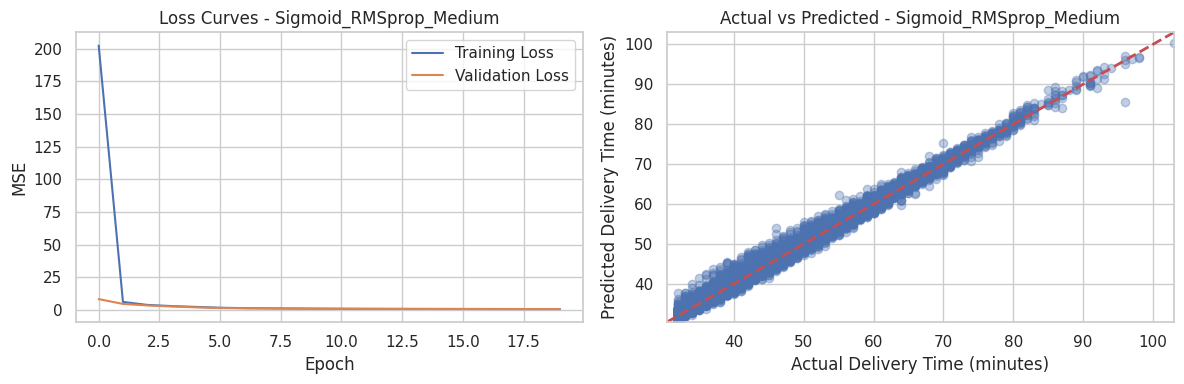

In [ ]:
tf.random.set_seed(42); np.random.seed(42)

model_C = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="sigmoid"),
    Dense(64,  activation="sigmoid"),
    Dense(1)
])
model_C.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
                loss="mse", metrics=["mae"])

print("Training model: Sigmoid_RMSprop_Medium")
hist_C = model_C.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=0
)

y_trn_C = model_C.predict(X_train_scaled).ravel()
y_tst_C = model_C.predict(X_test_scaled).ravel()


fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(hist_C.history["loss"], label="Training Loss")
ax[0].plot(hist_C.history["val_loss"], label="Validation Loss")
ax[0].set_title("Loss Curves - Sigmoid_RMSprop_Medium")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("MSE"); ax[0].legend()

lo = float(min(y_test.min(), y_tst_C.min())); hi = float(max(y_test.max(), y_tst_C.max()))
ax[1].scatter(y_test, y_tst_C, alpha=0.35)
ax[1].plot([lo,hi],[lo,hi],'r--',lw=2)
ax[1].set_xlim(lo,hi); ax[1].set_ylim(lo,hi)
ax[1].set_title("Actual vs Predicted - Sigmoid_RMSprop_Medium")
ax[1].set_xlabel("Actual Delivery Time (minutes)")
ax[1].set_ylabel("Predicted Delivery Time (minutes)")
plt.tight_layout(); plt.show()


In [ ]:
def print_block_C(title, yt, yp):
    mse = mean_squared_error(yt, yp); rmse = np.sqrt(mse)
    mae = mean_absolute_error(yt, yp); r2 = r2_score(yt, yp)
    print(f"\n{title} metrics for Sigmoid_RMSprop_Medium:")
    print(f"  MSE : {mse:.4f}\n  RMSE: {rmse:.4f}\n  MAE : {mae:.4f}\n  R2  : {r2:.4f}")

print_block_C("Train", y_train, y_trn_C)
print_block_C("Test",  y_test,  y_tst_C)


Train metrics for Sigmoid_RMSprop_Medium:
  MSE : 0.6519
  RMSE: 0.8074
  MAE : 0.5818
  R2  : 0.9925

Test metrics for Sigmoid_RMSprop_Medium:
  MSE : 0.6619
  RMSE: 0.8136
  MAE : 0.5826
  R2  : 0.9924
